In [ ]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('data/creditcard.csv')

# 2.Compare Genuine vs Fraudulent Transaction Amounts
# Class 0 = Genuine, Class 1 = Fraud
analysis = df.groupby('Class')['Amount'].agg(['mean', 'median', 'count'])

print("- EY FRAUD ANALYSIS REPORT -")
print(analysis)

# 3.logic check: Is fraud usually for small or large amounts?
if analysis.loc[1, 'mean'] > analysis.loc[0, 'mean']:
    print("\nInsight: Fraudulent transactions are higher on average than genuine ones.")
else:
    print("\nInsight: Fraudulent transactions are smaller on average (Low & Slow attack).")

- EY FRAUD ANALYSIS REPORT -
             mean  median   count
Class                            
0       88.291022   22.00  284315
1      122.211321    9.25     492

Insight: Fraudulent transactions are higher on average than genuine ones.


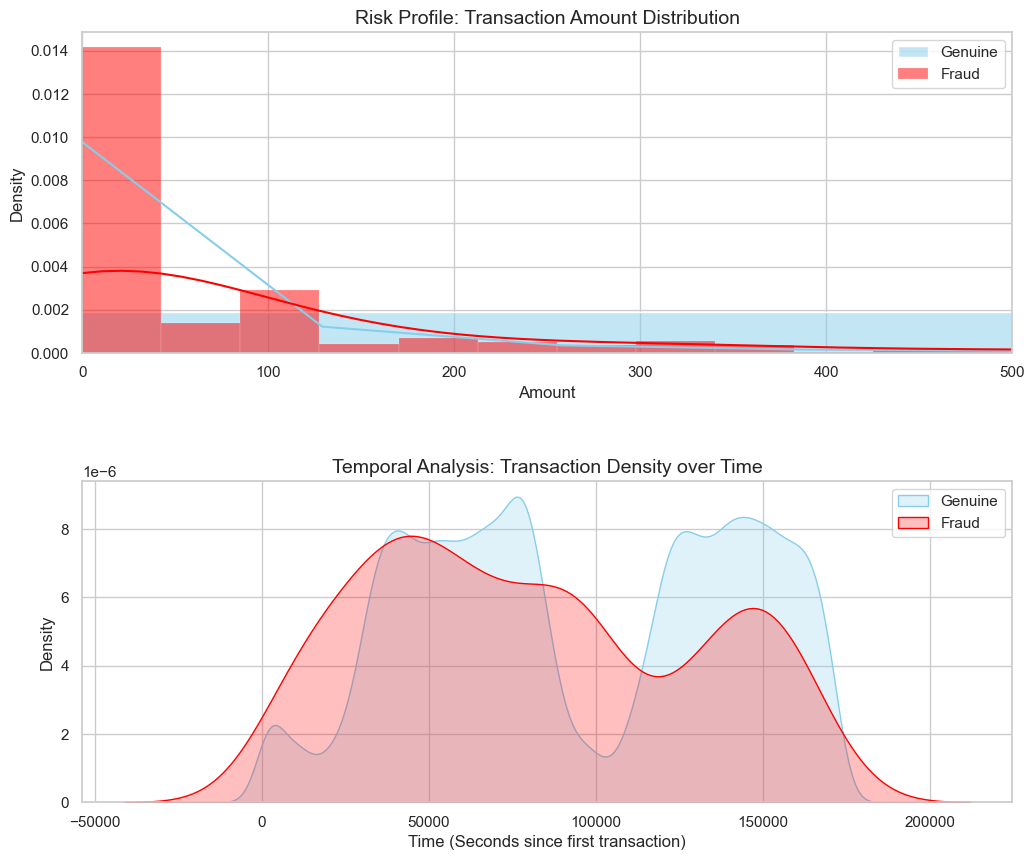

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1)
plt.subplots_adjust(hspace=0.4)

# 1. Transaction Amount Distribution (Log Scale for better visibility)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=ax1, color='skyblue', label='Genuine', kde=True, stat="density")
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=ax1, color='red', label='Fraud', kde=True, stat="density")
ax1.set_title('Risk Profile: Transaction Amount Distribution', fontsize=14)
ax1.set_xlim([0, 500])  # Zoom in to the most frequent transaction range
ax1.legend()

# 2. Transaction Time Distribution (Density Plot)
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Genuine', fill=True, ax=ax2, color='skyblue')
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', fill=True, ax=ax2, color='red')
ax2.set_title('Temporal Analysis: Transaction Density over Time', fontsize=14)
ax2.set_xlabel('Time (Seconds since first transaction)')
ax2.set_ylabel('Density')
ax2.legend()

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Scale 'Amount' and 'Time' (The only columns not yet scaled)
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# 3. Drop the original columns and keep the scaled ones
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# 4. Define Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 5. Split the data (80% Training, 20% Testing)
# use stratify to ensure both sets have the same % of fraud
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Preprocessing Audit ---")
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"Fraud cases in Test Set: {y_test.sum()}")

--- Preprocessing Audit ---
Training set size: 227845 samples
Testing set size: 56962 samples
Fraud cases in Test Set: 98


In [17]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Initialize SMOTE
sm = SMOTE(random_state=42)

# 2. Resample the training data only
# (Never resample the test set - we must keep the test set realistic!)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("--- Resampling Audit ---")
print(f"Original training shape: {Counter(y_train)}")
print(f"Resampled training shape: {Counter(y_train_res)}")

--- Resampling Audit ---
Original training shape: Counter({0: 227451, 1: 394})
Resampled training shape: Counter({0: 227451, 1: 227451})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Model
# We use a small number of trees (n_estimators=100) for speed
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model

model.fit(X_train_res, y_train_res)

# 3. Make predictions on the Test Set
y_pred = model.predict(X_test)

print("Training Completed")

Training Complete!


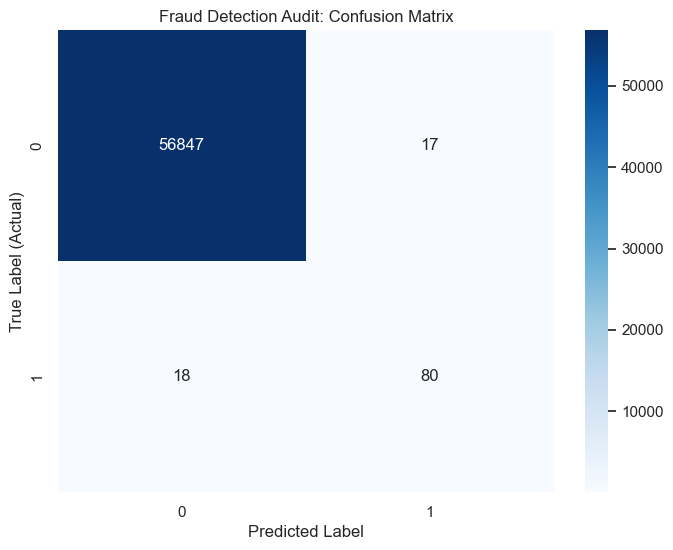


--- PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
# Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label (Actual)')
plt.title('Fraud Detection Audit: Confusion Matrix')
plt.show()

# Print the full report
print("\n--- PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))

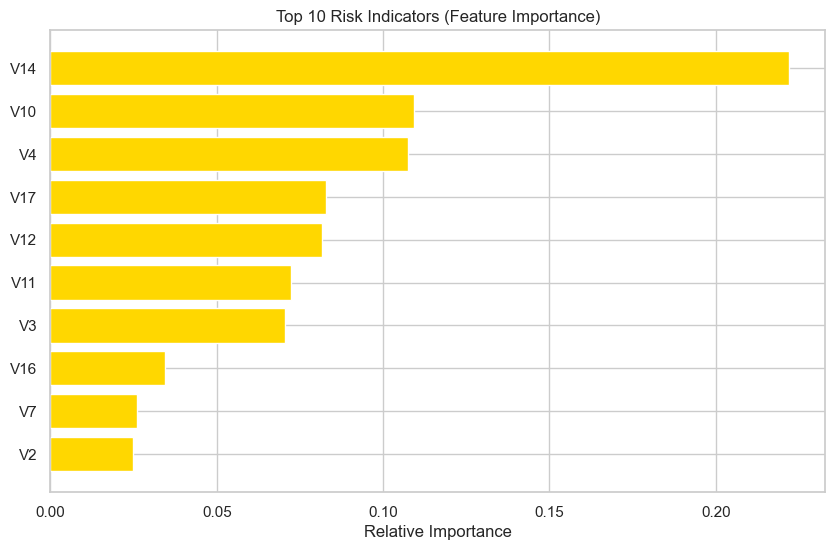

In [20]:
# Identify the risk indicators
import numpy as np

# Extract feature importance
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Risk Indicators (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='gold', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [21]:
import joblib

# Save the model and the scaler
joblib.dump(model, 'fraud_model.pkl')
joblib.dump(scaler, 'data_scaler.pkl')

print(" Model and Scaler saved as .pkl files")

 Model and Scaler saved as .pkl files


In [ ]:
def predict_transaction(transaction_data):
    """
    Simulates a real-time bank check.
    input: list of features [V1, V2... V28, Amount, Time]
    """
    # 1. Load the saved assets
    saved_model = joblib.load('fraud_model.pkl')
    saved_scaler = joblib.load('data_scaler.pkl')
    
    # 2. Convert to DataFrame (ensure columns match Training data)
    #   model expects 30 features (V1-V28 + scaled_amount + scaled_time)
    prediction = saved_model.predict(transaction_data)
    probability = saved_model.predict_proba(transaction_data)
    
    if prediction[0] == 1:
        print(f" ALERT: Fraud Detected! (Confidence: {probability[0][1]*100:.2f}%)")
    else:
        print(f" Transaction Approved. (Confidence: {probability[0][0]*100:.2f}%)")

In [23]:
# Pick a random Fraud sample (Class 1) from the test set
fraud_sample = X_test[y_test == 1].iloc[:1]

# Pick a random Genuine sample (Class 0) from the test set
genuine_sample = X_test[y_test == 0].iloc[:1]

print("Testing with a KNOWN FRAUD case:")
predict_transaction(fraud_sample)

print("\nTesting with a KNOWN GENUINE case:")
predict_transaction(genuine_sample)

Testing with a KNOWN FRAUD case:
 ALERT: Fraud Detected! (Confidence: 94.00%)

Testing with a KNOWN GENUINE case:
 Transaction Approved. (Confidence: 100.00%)


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Define the param grid
param_grid = {'n_estimators': [100,200],'max_depth': [10.20, None],
'bootstrap':[True]}

# Initialize the GridSearch
# Chose to use scoring='recall' as our goal is to catch those 18 missing fraud
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,
scoring ="recall",
cv=3,
n_jobs=-1, 
verbose=2) 

# 3. Fit the grid search to our resampled training data
print("Starting Grid Search... This may take a few minutes as we test multiple models.")
grid_search.fit(X_train_res, y_train_res)

# 4. Get the best model
best_model = grid_search.best_params_
print(f"\n✅ Best Parameters Found: {best_model}")

# 5. Evaluate the 'Tuned' Model
y_pred_tuned = grid_search.best_estimator_.predict(X_test)

                           
                           
                           

Starting Grid Search... This may take a few minutes as we test multiple models.
Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\reust\Downloads\Fraud_dectection_project\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\reust\Downloads\Fraud_dectection_project\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\reust\Downloads\Fraud_dectection_project\venv\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\User


✅ Best Parameters Found: {'bootstrap': True, 'max_depth': None, 'n_estimators': 100}


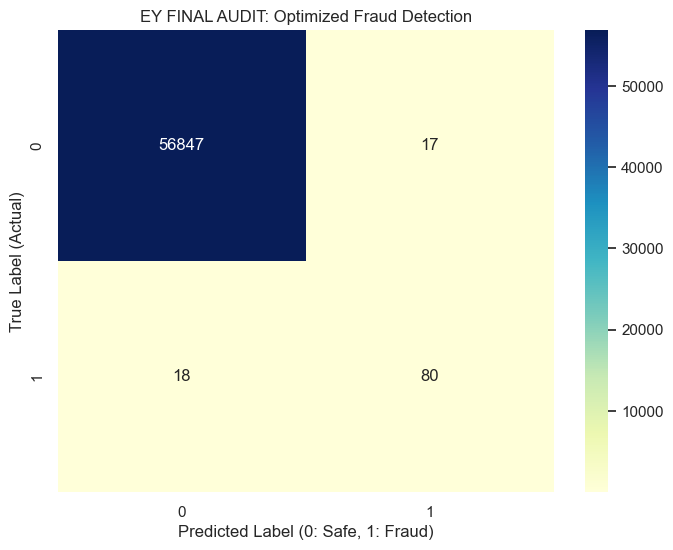


--- FINAL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Initial Missed Frauds: 18
Final Missed Frauds: 18


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the best model found by the Grid Search
final_model = grid_search.best_estimator_

# 2. Make final predictions
y_pred_final = final_model.predict(X_test)

# 3. Create the Confusion Matrix
final_cm = confusion_matrix(y_test, y_pred_final)

# 4. Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('EY FINAL AUDIT: Optimized Fraud Detection')
plt.xlabel('Predicted Label (0: Safe, 1: Fraud)')
plt.ylabel('True Label (Actual)')
plt.show()

# 5. Final Report
print("\n- FINAL PERFORMANCE REPORT -")
print(classification_report(y_test, y_pred_final))

# Compare the "Missing" count
print(f"Initial Missed Frauds: 18")
print(f"Final Missed Frauds: {final_cm[1][0]}")